# ConvNeXt-Base Training Pipeline

Fine-tunes a pretrained ConvNeXt-Base backbone for 3-class chest X-ray classification: `NORMAL`, `BACTERIAL_PNEUMONIA`, and `VIRAL_PNEUMONIA`.

## Training strategy

| Phase | Epochs | Layers trained | Learning rate |
|---|---|---|---|
| 1 — Head warm-up | 1–3 | Classifier head only | `1e-4` |
| 2 — Fine-tuning | 4+ | Head + last 4 feature stages | `1e-5` |

ConvNeXt uses large 7×7 depthwise convolutions within each stage. Partial unfreezing via `model.features[-4:]` is important — fine-tuning the entire network from scratch would overwrite the rich ImageNet representations with too few medical examples.

## Key design decisions
- **Class-weighted loss**: corrects for class imbalance across the three pneumonia types
- **Label smoothing (0.05)**: mild regularisation on logit targets
- **Mixed precision (AMP)**: enabled when CUDA is available
- **Early stopping (patience=4)**: prevents overfitting on this relatively small medical dataset (~5,000 training images)

## Outputs
- `ConvNeXt_pneumonia.pth` — best model weights
- `classes.json` — class index-to-label mapping

In [1]:
# Install this once
!pip install import-ipynb
!pip install import-ipynb scikit-learn

## DataLoader Import

Imports the cleaned datasets and preprocessing transforms from `Preprocessing_Pipeline.ipynb`. This gives us:
- `prep.train_dataset` / `prep.val_dataset` / `prep.test_dataset` — `ImageFolder` datasets after autoencoder-based outlier removal
- `prep.train_dataset.classes` — ordered class name list used to configure the model output layer

The full preprocessing pipeline (CLAHE, noise reduction, normalisation, augmentations) is already embedded in each dataset object. No additional transforms are applied here.

Cleaning datasets using autoencoder...

Processing class 0...


Class 0 Epoch 1, Total Loss: 33.1817


Class 0 Epoch 2, Total Loss: 19.1869


Class 0 Epoch 3, Total Loss: 17.9960


Class 0: removed 127 samples

Processing class 1...


...

Class 1: removed 8 samples

Processing class 2...


Class 2 Epoch 1, Total Loss: 4.1433


Class 2 Epoch 2, Total Loss: 4.0224


Class 2: removed 5 samples

Balancing train dataset...
Before balancing: {np.int64(0): np.int64(2403), np.int64(1): np.int64(1273), np.int64(2): np.int64(1277)}
After balancing: {np.int64(0): np.int64(1273), np.int64(1): np.int64(1273), np.int64(2): np.int64(1273)}
Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 3819
Validation size: 186
Test size: 604


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0376734].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0416646].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0416646].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0815775].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0536385].


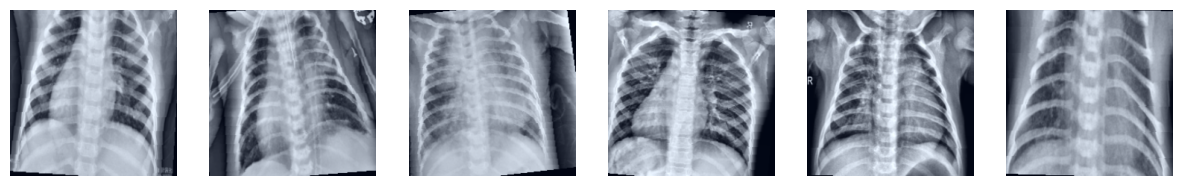

🔹 Train Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 1273 (33.33%)
NORMAL: 1273 (33.33%)
VIRAL_PNEUMONIA: 1273 (33.33%)

🔹 Test Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 234 (38.74%)
NORMAL: 227 (37.58%)
VIRAL_PNEUMONIA: 143 (23.68%)
🔹 Validation Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 62 (33.33%)
NORMAL: 62 (33.33%)
VIRAL_PNEUMONIA: 62 (33.33%)


In [2]:
import import_ipynb
import Preprocessing_Pipeline as prep

In [3]:
import copy
import json
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import models

from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [5]:
train_loader = DataLoader(prep.train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(prep.val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(prep.test_dataset, batch_size=32, shuffle=False)

NUM_CLASSES = len(prep.train_dataset.classes)

## ConvNeXt-Base Architecture

ConvNeXt-Base (~89M parameters) is a modernised pure-CNN architecture that incorporates design principles from Vision Transformers: large 7×7 depthwise convolutions, LayerNorm instead of BatchNorm, inverted bottleneck blocks, and GELU activations.

The standard classifier head (`classifier[2]: Linear(in_features → 1000)`) is replaced with:
```
Linear(in_features → num_classes)
```
ConvNeXt's classifier already includes `AdaptiveAvgPool2d + LayerNorm` before the final linear, providing implicit global regularisation before the class logits.

In [6]:
model = models.convnext_base(
    weights=models.ConvNeXt_Base_Weights.DEFAULT
)
model.classifier[2] = nn.Sequential(
    nn.LayerNorm(model.classifier[2].in_features),
    nn.Dropout(0.5),
    nn.Linear(model.classifier[2].in_features, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(device)

### Phase 1: Head-Only Training

All backbone parameters are frozen — only the newly added classifier head will receive gradient updates for the first `FREEZE_EPOCHS` epochs. This prevents the randomly-initialised head from destroying pretrained feature representations during early training when its gradients are large and noisy.

In [7]:
for param in model.parameters():
    param.requires_grad = False

# Train classifier first
for param in model.classifier.parameters():
    param.requires_grad = True

### Class Weighting

Computes inverse-frequency weights for each class: `weight[i] = total_samples / count[i]`. This means errors on the small `VIRAL_PNEUMONIA` class are penalised proportionally more than errors on the larger `BACTERIAL_PNEUMONIA` class. The weights are passed directly to `CrossEntropyLoss`, making the loss surface reflect clinical priority rather than dataset frequency.

In [8]:
counts = Counter(prep.train_dataset.targets)

total = sum(counts.values())

class_weights = [
    total / counts[i]
    for i in range(len(counts))
]

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

## Training Configuration

| Parameter | Value | Rationale |
|---|---|---|
| Loss function | `CrossEntropyLoss` (weighted) | Class weights inversely proportional to sample count; penalises minority-class errors more heavily |
| Label smoothing | `0.05` | Mild regularisation on logit targets |
| Optimizer | `Adam` | Adaptive per-parameter learning rates; robust without extensive LR tuning |
| Head LR (Phase 1) | `1e-4` | Fast convergence for the new classifier head |
| Fine-tune LR (Phase 2) | `1e-5` | Conservative rate to avoid overwriting ConvNeXt's large-kernel features |
| Weight decay | `1e-4` | L2 regularisation |
| LR scheduler | `ReduceLROnPlateau` | Multiplies LR by 0.3 after 2 epochs without val loss improvement |
| Max epochs | `20` | Upper bound; early stopping typically triggers earlier |
| Freeze epochs | `3` | Epochs before last-4-stage unfreezing |
| Early stop patience | `4` | Epochs to wait before halting training |
| Gradient clipping | `2.0` | Caps global gradient norm to prevent destructive updates from bad batches |

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.3)

EPOCHS = 20
FREEZE_EPOCHS = 3
PATIENCE = 4

best_val_loss = float('inf')
epochs_no_improve = 0

best_model_weights = copy.deepcopy(model.state_dict())
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

C:\Users\noora\AppData\Local\Temp\ipykernel_36668\4167080889.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


## Training Loop

`train_one_epoch` runs one full pass over the training set. Key implementation details:

- **Mixed precision** (`torch.cuda.amp.autocast`): forward pass computes in float16 where safe, reducing GPU memory and increasing throughput. `GradScaler` rescales gradients back to float32 before the optimizer step to prevent underflow
- **Gradient clipping** (`clip_grad_norm_=2.0`): caps the global L2 norm of all gradients, preventing a single bad batch from causing a destructive parameter update
- `optimizer.zero_grad()` is called before the forward pass (not after), which is the recommended pattern when using gradient scaling
- Returns average batch loss and per-epoch accuracy for tracking

In [10]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=loss.item())

    return (total_loss / len(loader), correct / total)

## Evaluation Loop

`evaluate` runs a full pass over a dataloader under `torch.no_grad()`, which disables gradient computation and approximately halves memory usage. This function is used identically for both validation (after each training epoch) and final test evaluation, ensuring both are computed the same way.

In [11]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return (
        total_loss / len(loader),
        correct / total,
        np.array(all_probs),
        np.array(all_preds),
        np.array(all_labels)
    )

## Main Training Loop

Runs the full training cycle with two-phase fine-tuning, live loss plotting, and early stopping:

1. **Epochs 1–`FREEZE_EPOCHS`**: only the classification head is trained; backbone is frozen
2. **At epoch `FREEZE_EPOCHS`**: the last 4 feature stages are unfrozen and the optimizer is rebuilt at a lower learning rate to fine-tune pretrained weights gently
3. **Each epoch**: train → validate → step the LR scheduler → check early stopping → update live loss plot
4. **Best model checkpointing**: the state dict is saved in memory whenever validation loss reaches a new minimum. If early stopping triggers, training ends with the best weights already captured and ready to restore


Epoch 1/20


Training:   0%|          | 0/120 [00:00<?, ?it/s]C:\Users\noora\AppData\Local\Temp\ipykernel_36668\3860615245.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
                                                                       

Train Loss: 0.8920 | Train Acc: 0.6130
Val Loss: 0.6306 | Val Acc: 0.8172
Generalization Gap: -0.2042
✅ Good Bias-Variance Tradeoff
✅ Best model updated


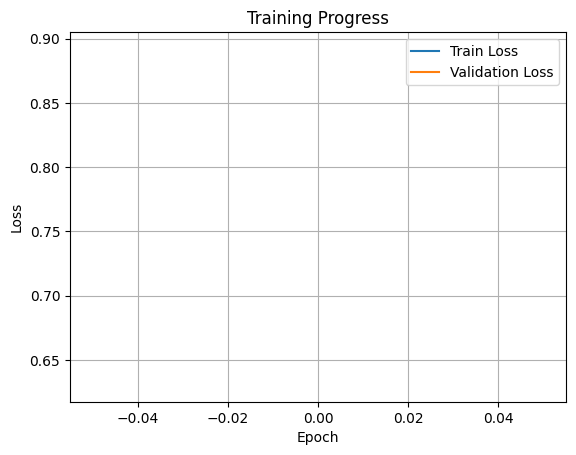


Epoch 2/20


Train Loss: 0.7338 | Train Acc: 0.7002
Val Loss: 0.5737 | Val Acc: 0.8172
Generalization Gap: -0.1170
✅ Good Bias-Variance Tradeoff
✅ Best model updated


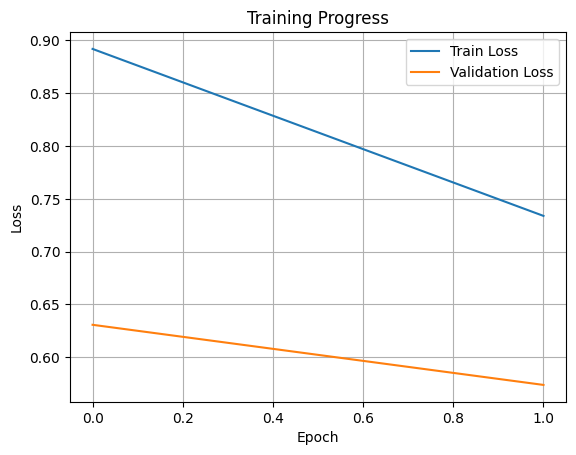


Epoch 3/20


Train Loss: 0.6958 | Train Acc: 0.7266
Val Loss: 0.5517 | Val Acc: 0.8441
Generalization Gap: -0.1175
✅ Good Bias-Variance Tradeoff
✅ Best model updated


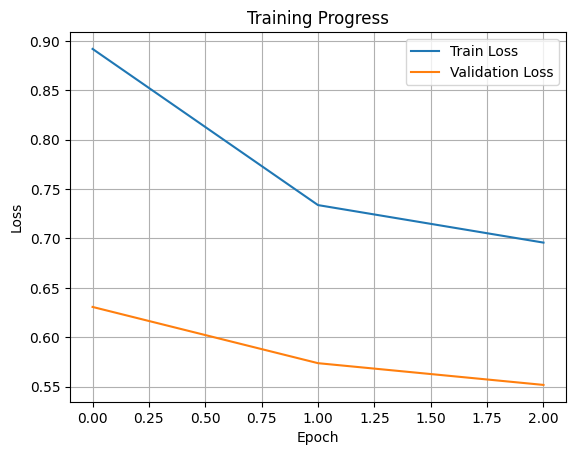


Epoch 4/20
🚀 Unfreezing ConvNeXt backbone...


Train Loss: 0.6772 | Train Acc: 0.7313
Val Loss: 0.5356 | Val Acc: 0.8387
Generalization Gap: -0.1074
✅ Good Bias-Variance Tradeoff
✅ Best model updated


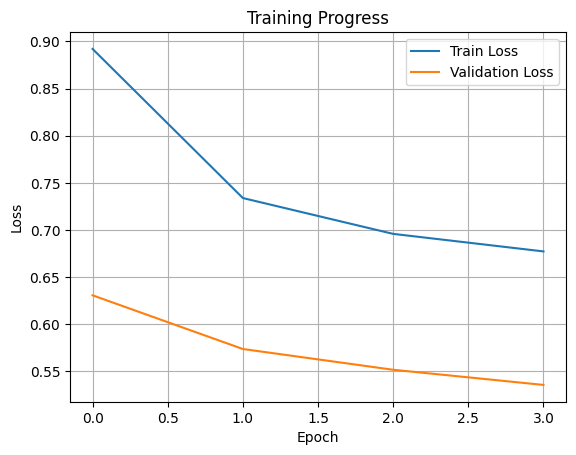


Epoch 5/20


Train Loss: 0.6494 | Train Acc: 0.7507
Val Loss: 0.5163 | Val Acc: 0.8387
Generalization Gap: -0.0880
✅ Good Bias-Variance Tradeoff
✅ Best model updated


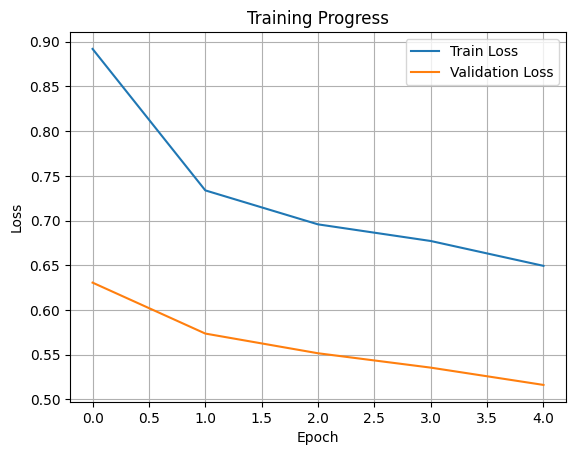


Epoch 6/20


Train Loss: 0.6226 | Train Acc: 0.7549
Val Loss: 0.5125 | Val Acc: 0.8387
Generalization Gap: -0.0838
✅ Good Bias-Variance Tradeoff
✅ Best model updated


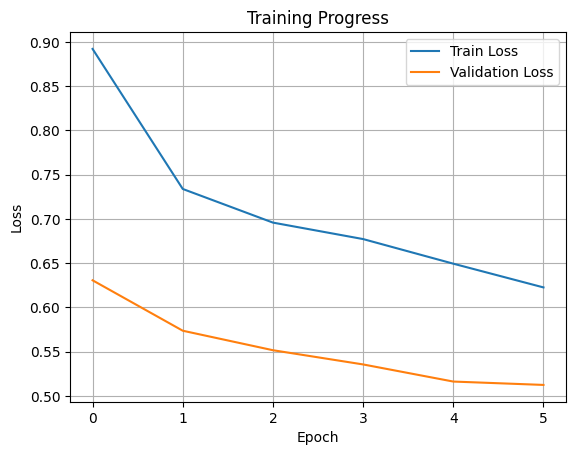


Epoch 7/20


Train Loss: 0.6159 | Train Acc: 0.7562
Val Loss: 0.5109 | Val Acc: 0.8495
Generalization Gap: -0.0932
✅ Good Bias-Variance Tradeoff
✅ Best model updated


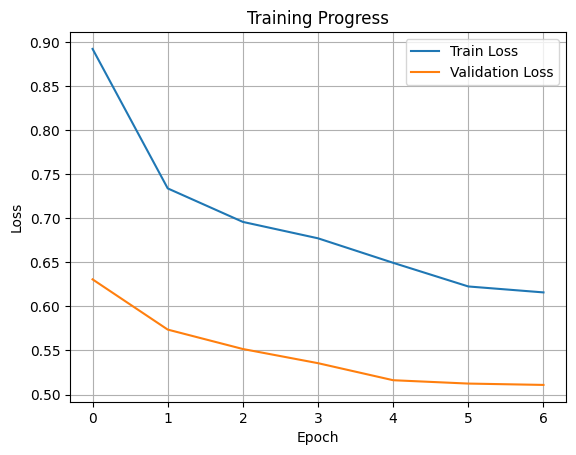


Epoch 8/20


Train Loss: 0.6055 | Train Acc: 0.7690
Val Loss: 0.5019 | Val Acc: 0.8548
Generalization Gap: -0.0858
✅ Good Bias-Variance Tradeoff
✅ Best model updated


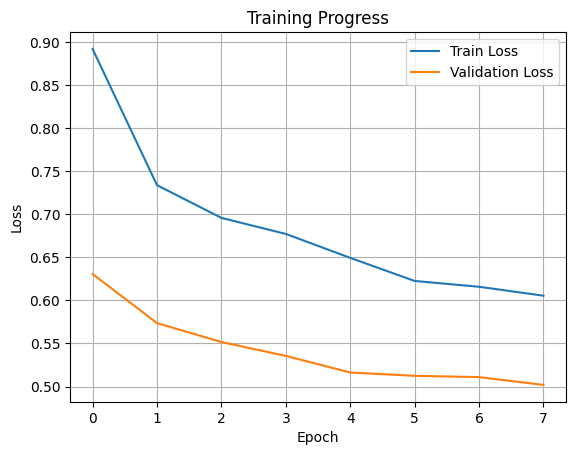


Epoch 9/20


Train Loss: 0.5905 | Train Acc: 0.7793
Val Loss: 0.4984 | Val Acc: 0.8548
Generalization Gap: -0.0756
✅ Good Bias-Variance Tradeoff
✅ Best model updated


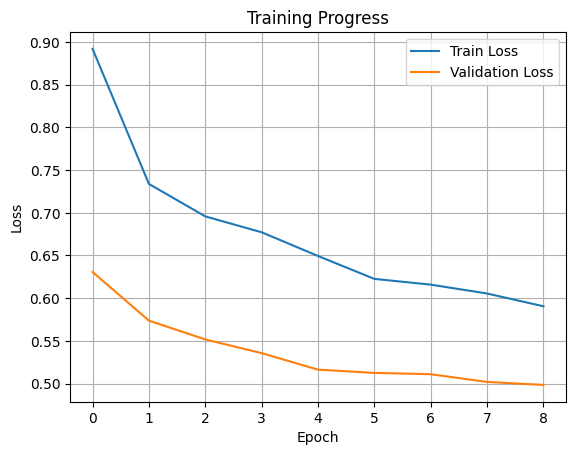


Epoch 10/20


Train Loss: 0.5920 | Train Acc: 0.7759
Val Loss: 0.4926 | Val Acc: 0.8602
Generalization Gap: -0.0844
✅ Good Bias-Variance Tradeoff
✅ Best model updated


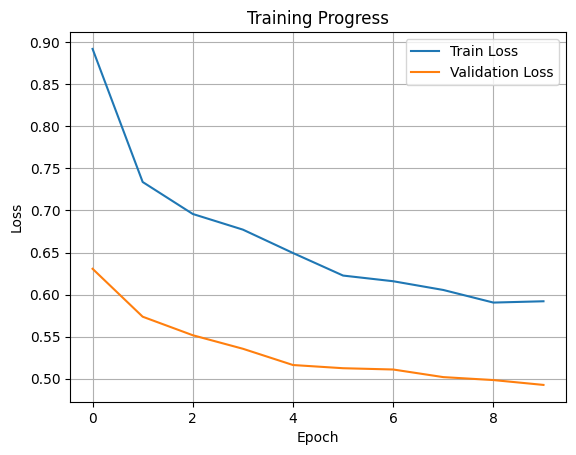


Epoch 11/20


Train Loss: 0.5789 | Train Acc: 0.7871
Val Loss: 0.4996 | Val Acc: 0.8495
Generalization Gap: -0.0623
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs


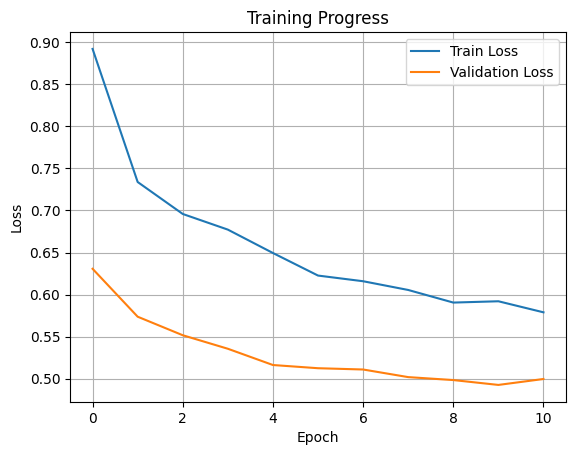


Epoch 12/20


Train Loss: 0.5760 | Train Acc: 0.7790
Val Loss: 0.4831 | Val Acc: 0.8548
Generalization Gap: -0.0758
✅ Good Bias-Variance Tradeoff
✅ Best model updated


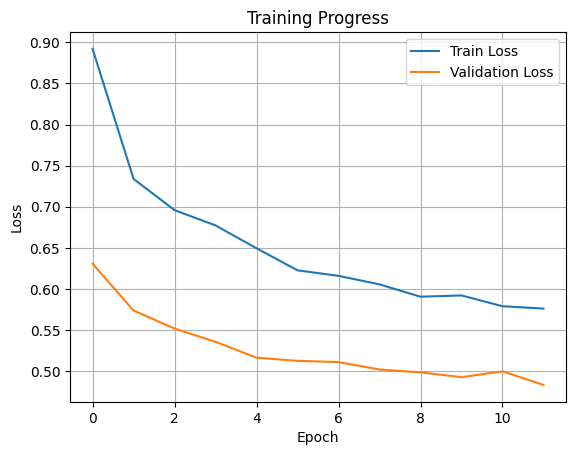


Epoch 13/20


Train Loss: 0.5629 | Train Acc: 0.7921
Val Loss: 0.4849 | Val Acc: 0.8602
Generalization Gap: -0.0681
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs


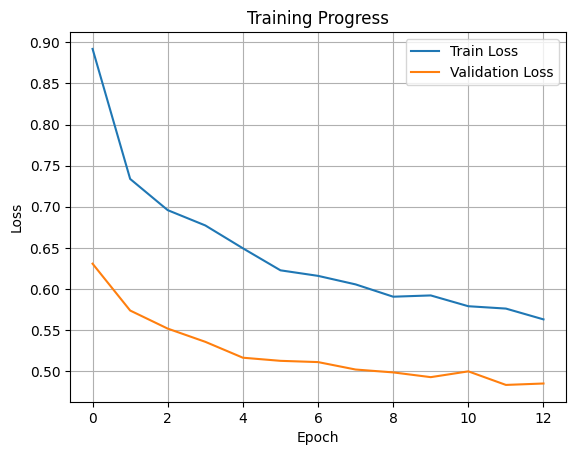


Epoch 14/20


Train Loss: 0.5670 | Train Acc: 0.8002
Val Loss: 0.4892 | Val Acc: 0.8548
Generalization Gap: -0.0546
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 2 epochs


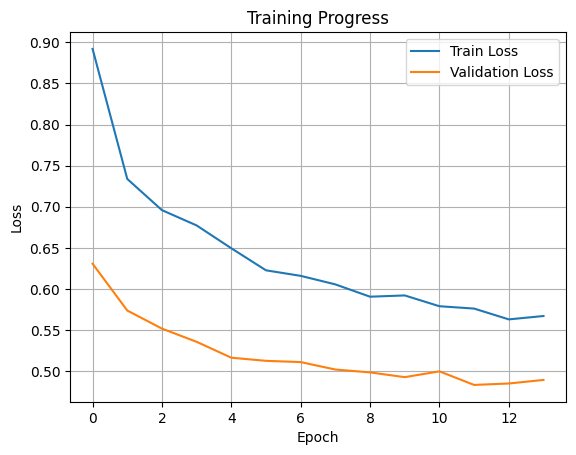


Epoch 15/20


Train Loss: 0.5612 | Train Acc: 0.7918
Val Loss: 0.4789 | Val Acc: 0.8656
Generalization Gap: -0.0738
✅ Good Bias-Variance Tradeoff
✅ Best model updated


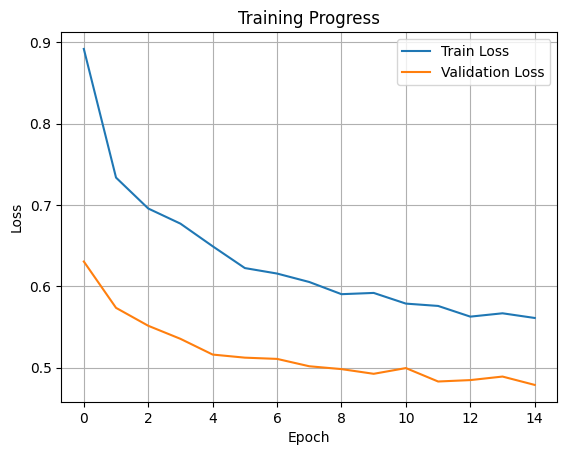


Epoch 16/20


Train Loss: 0.5543 | Train Acc: 0.7984
Val Loss: 0.4795 | Val Acc: 0.8602
Generalization Gap: -0.0618
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs


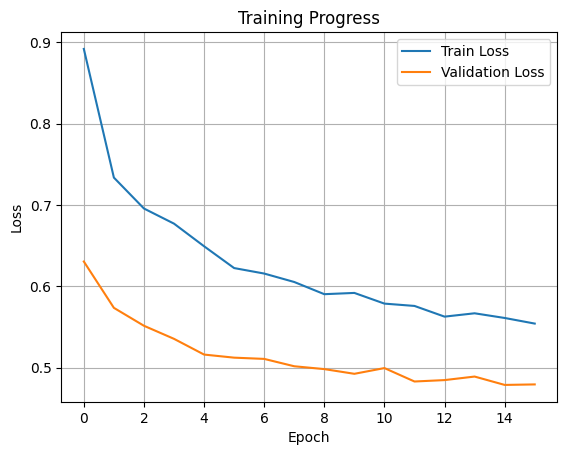


Epoch 17/20


Train Loss: 0.5577 | Train Acc: 0.8007
Val Loss: 0.4735 | Val Acc: 0.8602
Generalization Gap: -0.0595
✅ Good Bias-Variance Tradeoff
✅ Best model updated


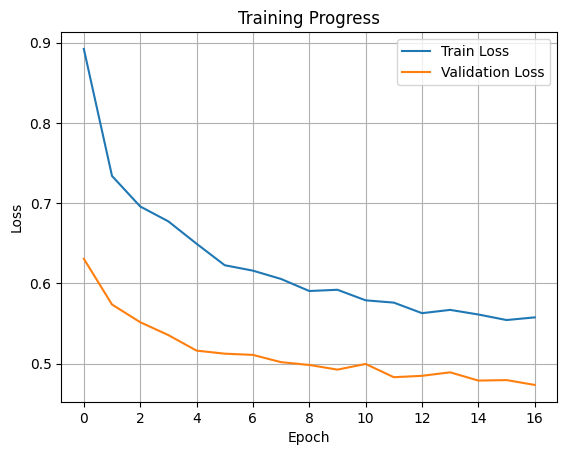


Epoch 18/20


Train Loss: 0.5468 | Train Acc: 0.8041
Val Loss: 0.4712 | Val Acc: 0.8656
Generalization Gap: -0.0615
✅ Good Bias-Variance Tradeoff
✅ Best model updated


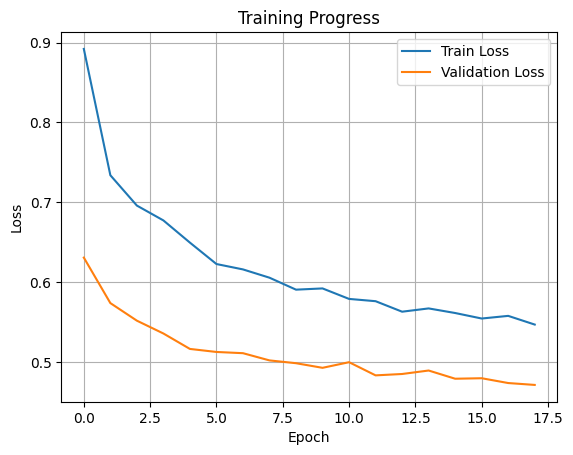


Epoch 19/20


Train Loss: 0.5473 | Train Acc: 0.8089
Val Loss: 0.4664 | Val Acc: 0.8656
Generalization Gap: -0.0567
✅ Good Bias-Variance Tradeoff
✅ Best model updated


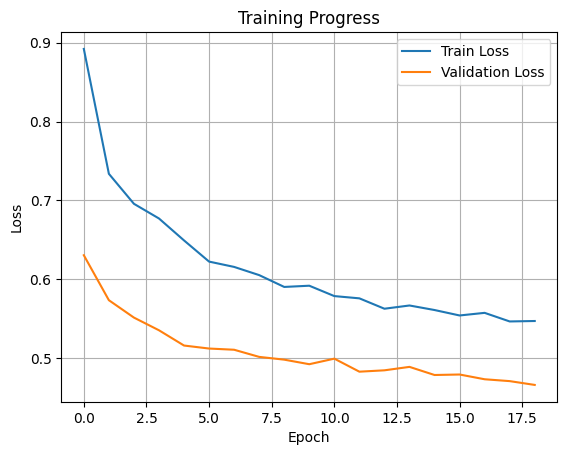


Epoch 20/20


Train Loss: 0.5378 | Train Acc: 0.8109
Val Loss: 0.4601 | Val Acc: 0.8763
Generalization Gap: -0.0654
✅ Good Bias-Variance Tradeoff
✅ Best model updated


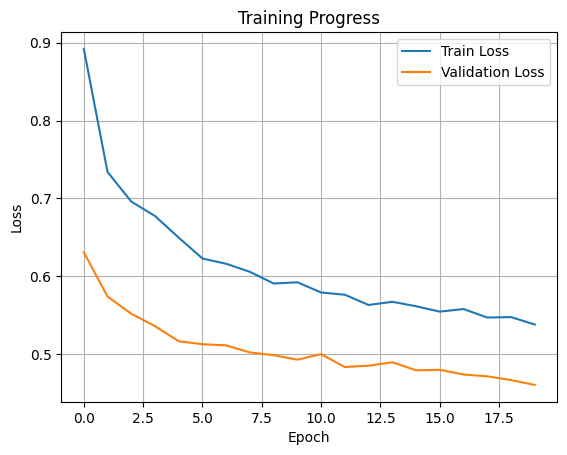

In [12]:
plt.ion()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    if epoch == FREEZE_EPOCHS:
        print("🚀 Unfreezing ConvNeXt backbone...")
        for param in model.features[-4:].parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-5,
            weight_decay=1e-4
        )
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.3)
    
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    gap = train_acc - val_acc

    print(f"Generalization Gap: {gap:.4f}")

    if gap > 0.10:
        print(
            "⚠️ Possible Overfitting "
            "(High Variance)"
        )
    elif gap < 0.02 and val_acc < 0.75:
        print(
            "⚠️ Possible Underfitting "
            "(High Bias)"
        )
    else:
        print("✅ Good Bias-Variance Tradeoff")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        print("✅ Best model updated")
    else:
        epochs_no_improve += 1
        print(
            f"⚠️ No improvement for "
            f"{epochs_no_improve} epochs"
        )
    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered")
        break

    plt.clf()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Progress")
    plt.legend()
    plt.grid()
    plt.pause(0.1)

plt.ioff()
plt.show()

## Restore Best Weights and Evaluate

Restores the model state dict that achieved the lowest validation loss during training, then runs a single final evaluation on the held-out test set. The test set is touched only here — it was never used for training decisions or scheduler stepping.

In [13]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [14]:
test_loss, test_acc, probs, preds, labels = evaluate(model, test_loader)
print("TEST RESULTS:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

TEST RESULTS:
Test Loss: 0.5444
Test Accuracy: 0.8692


### F1 Score

Weighted F1 accounts for class imbalance by averaging per-class F1 scores weighted by support (number of true instances per class). This is a more honest summary metric than accuracy for an imbalanced 3-class problem.

In [15]:
f1 = f1_score(labels, preds, average='weighted')
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8714


In [16]:
torch.save(model.state_dict(), "ConvNeXt_pneumonia.pth")

import json
with open("classes.json", "w") as f:
    json.dump(prep.train_dataset.classes, f)

### Classification Report

Per-class breakdown of precision, recall, and F1-score on the test set. This is more informative than overall accuracy for an imbalanced dataset — a model that always predicts `NORMAL` or `BACTERIAL_PNEUMONIA` could still score high accuracy while completely missing `VIRAL_PNEUMONIA`. The per-class recall column is especially important in a medical screening context where false negatives carry clinical risk.

In [17]:
print(
    classification_report(labels, preds, target_names=prep.train_dataset.classes)
)

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.91      0.94      0.92       234
             NORMAL       0.97      0.80      0.87       227
    VIRAL_PNEUMONIA       0.71      0.87      0.78       143

           accuracy                           0.87       604
          macro avg       0.86      0.87      0.86       604
       weighted avg       0.88      0.87      0.87       604



## ROC-AUC Curves

In [18]:
labels_bin = label_binarize(
    labels,
    classes=np.arange(NUM_CLASSES)
)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):

    fpr[i], tpr[i], _ = roc_curve(
        labels_bin[:, i],
        probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

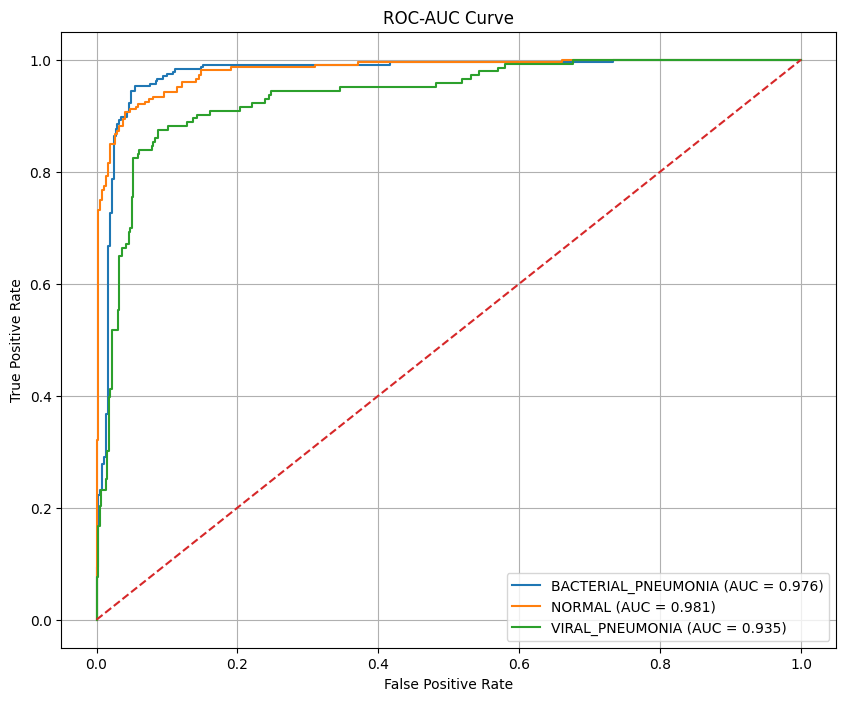

In [19]:
plt.figure(figsize=(10, 8))

for i in range(NUM_CLASSES):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{prep.train_dataset.classes[i]} "
              f"(AUC = {roc_auc[i]:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve")

plt.legend()
plt.grid()

plt.show()

In [20]:
overall_auc = roc_auc_score(
    labels_bin,
    probs,
    multi_class='ovr'
)

print(
    f"\nOverall ROC-AUC Score: "
    f"{overall_auc:.4f}"
)


Overall ROC-AUC Score: 0.9641


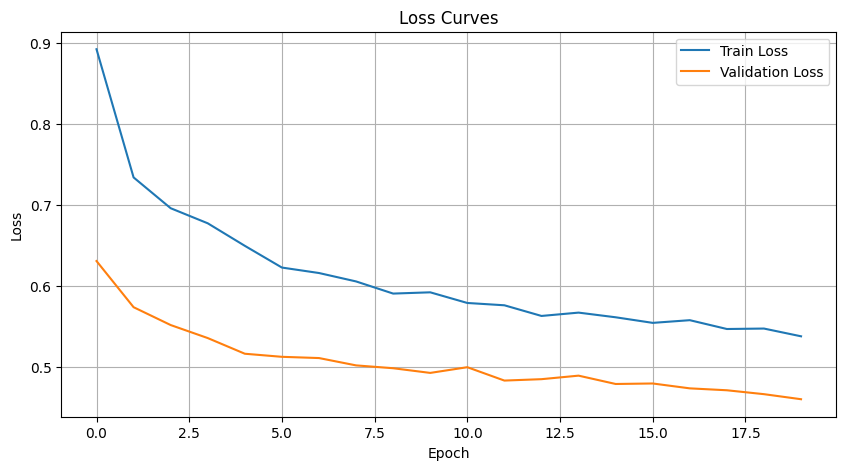

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curves")

plt.legend()
plt.grid()

plt.show()

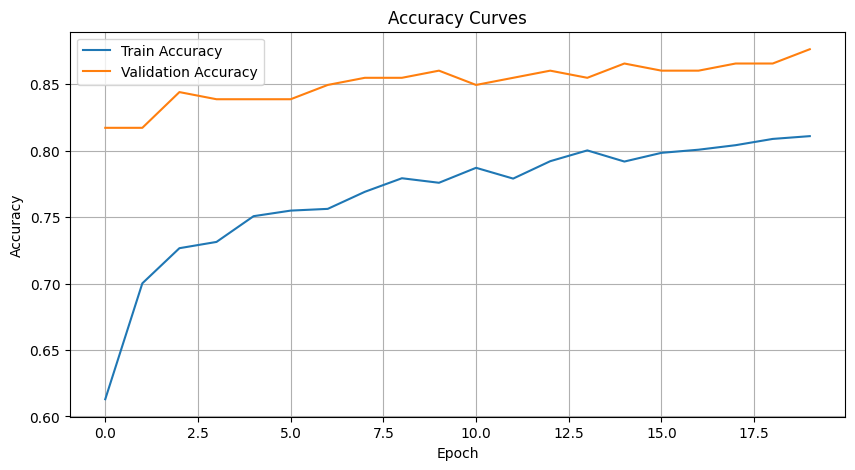

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy Curves")

plt.legend()
plt.grid()

plt.show()